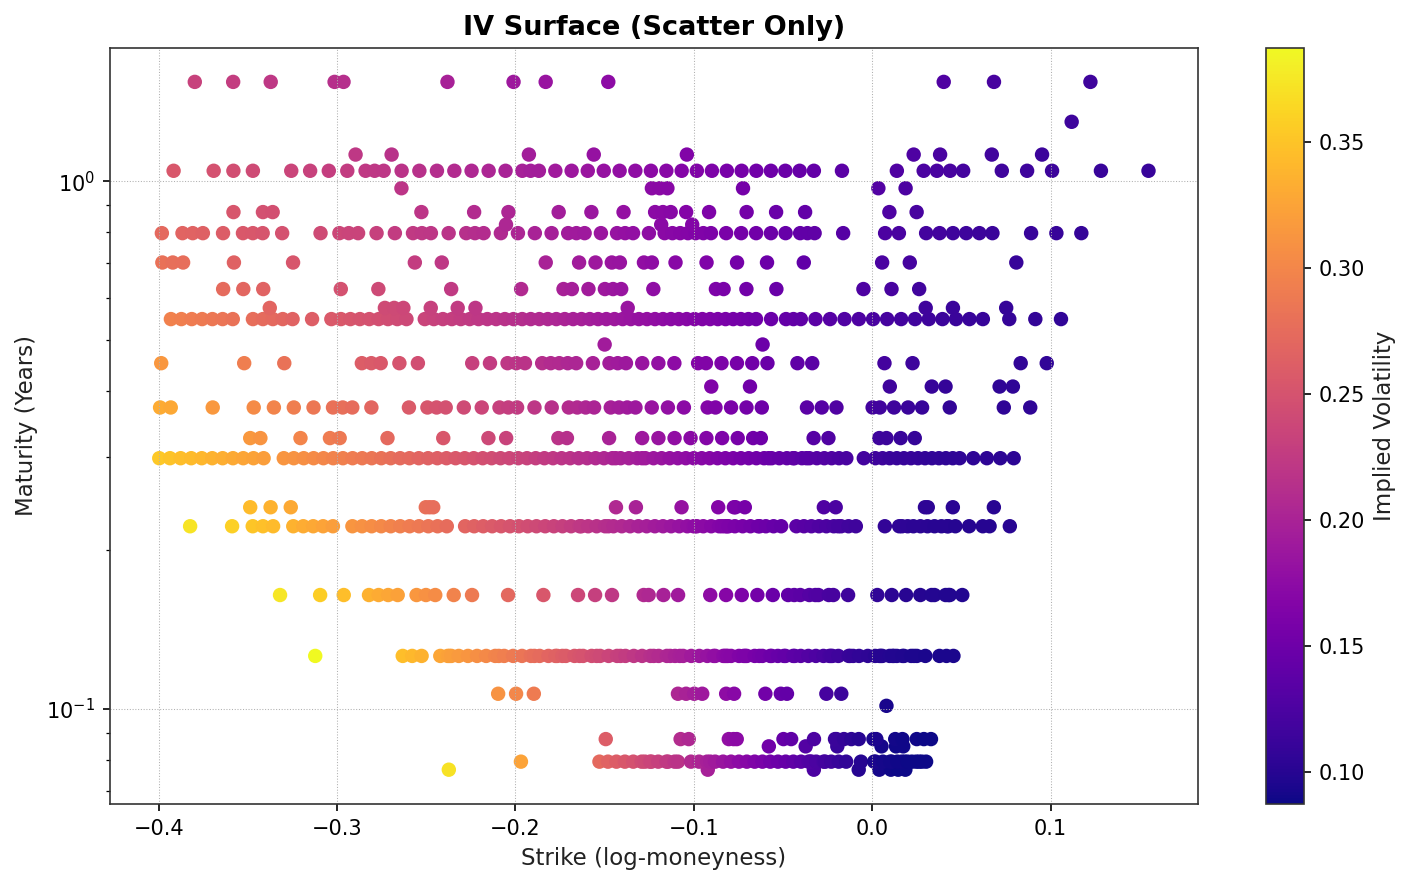

In [1]:
import pandas as pd
import numpy as np
import sys, os
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

vol="heston"

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from generation.utils import plot_iv_surface_scatter, preprocess_and_filter_otm, build_market_surfaces,  plot_param_grid, load_effr_rates_csv
from models.framework import DeepONet, MLP, BaseModel


df = pd.read_csv("C:/Users/Nils/nn_stochvol_calibrations/real_calibration/data_download.csv")
rates = load_effr_rates_csv("C:/Users/Nils/nn_stochvol_calibrations/real_calibration/EFFR.csv")

df = preprocess_and_filter_otm(df, rates, q=0.016)
surfaces = build_market_surfaces(df)
plot_iv_surface_scatter(surfaces[-1]["iv_surface"],surfaces[-1]["grid"]["strikes"],np.exp(surfaces[-1]["grid"]["maturities"]))

In [2]:
model_path=f"C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/{vol}/irregular/deeponet.pth"
x = DeepONet.load(model_path)
deeponet_res = []
for surface in surfaces:
    res = x.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    deeponet_res.append(res)

Loaded DeepONet from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/heston/irregular/deeponet.pth


In [6]:
deeponet_res

[{'theta_hat': array([ 3.99954744,  0.04126721,  0.01003437,  1.01657305, -0.75237277]),
  'error_rel_dict': None,
  'rmse': 0.0037547280080616474,
  'runtime_ms': 5549.684900001012,
  'optimizer': 'lm',
  'date': Timestamp('2020-01-02 00:00:00')},
 {'theta_hat': array([ 3.94429742,  0.035736  ,  0.02813925,  0.93332187, -0.83131053]),
  'error_rel_dict': None,
  'rmse': 0.0032710174564272165,
  'runtime_ms': 6431.437999999616,
  'optimizer': 'lm',
  'date': Timestamp('2020-02-03 00:00:00')},
 {'theta_hat': array([ 3.99954772,  0.05422095,  0.11592174,  1.8784937 , -0.7558617 ]),
  'error_rel_dict': None,
  'rmse': 0.007810397073626518,
  'runtime_ms': 902.5053000004846,
  'optimizer': 'lm',
  'date': Timestamp('2020-03-02 00:00:00')},
 {'theta_hat': array([ 0.58050043,  0.24999605,  0.24999738,  1.45948772, -0.9146938 ]),
  'error_rel_dict': None,
  'rmse': 0.033724624663591385,
  'runtime_ms': 3398.3009999974456,
  'optimizer': 'lm',
  'date': Timestamp('2020-04-01 00:00:00')},
 {'th

In [4]:
model_path=f"C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/{vol}/irregular/mlp.pth"
y = MLP.load(model_path)
mlp_res = []
analytic_res = []
for surface in surfaces:
    res = y.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    mlp_res.append(res)
    
    if vol == "heston":
        res_a = y.calibrate_heston_analytic(surface, optimiser="lm",  maxiter=500)
        res_a["date"] = surface["date"]
        analytic_res.append(res_a)

Loaded MLP from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/heston/irregular/mlp.pth


KeyboardInterrupt: 

In [5]:
save_path=f"C:/Users/Nils/nn_stochvol_calibrations/real_calibration/plots/{vol}"

if vol == "heston":
    plot_param_grid([deeponet_res, mlp_res, analytic_res],["DeepONet","MLP (bil. interp.)","analytic"], PARAM_NAMES=y.param_names, out_dir=save_path)
else:
    plot_param_grid([deeponet_res, mlp_res],["DeepONet","MLP (bil. interp.)"], PARAM_NAMES=y.param_names, out_dir=save_path)

KeyError: 'date'

In [ ]:
Saved plot to C:/Users/Nils/nn_stochvol_calibrations/real_calibration/plots/rbergomi\param_grid_plot.png

Average Calibration Runtime (ms):
model
DeepONet              9257.881318
MLP (bil. interp.)    1396.941217
Name: runtime_ms, dtype: float64

Average RMSE:
model
DeepONet              0.004586
MLP (bil. interp.)    0.004627
Name: rmse, dtype: float64

## Validation of some results

In [6]:
len(deeponet_res)

60

RMSE:  0.015262379


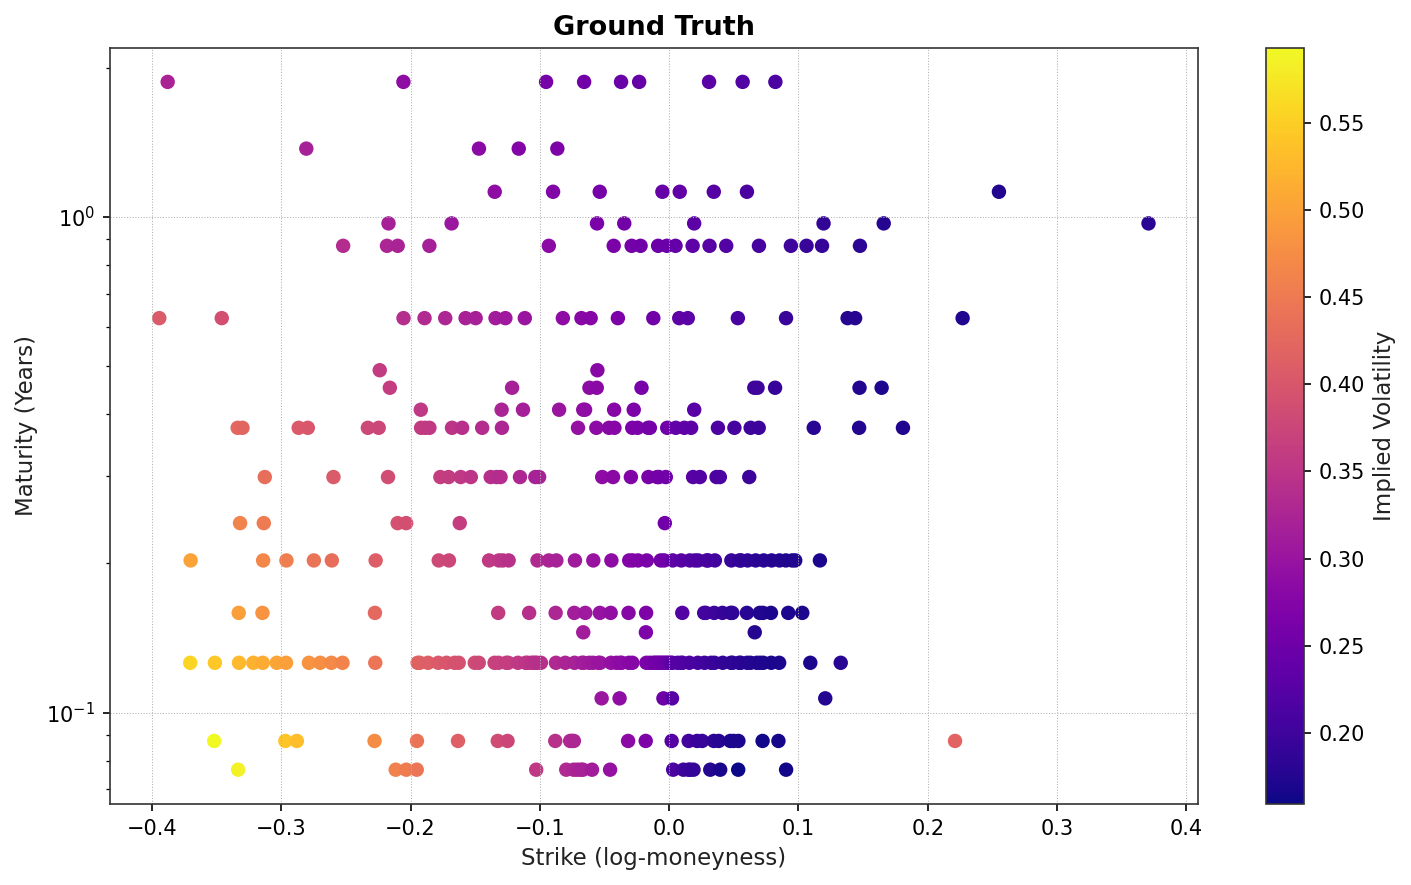

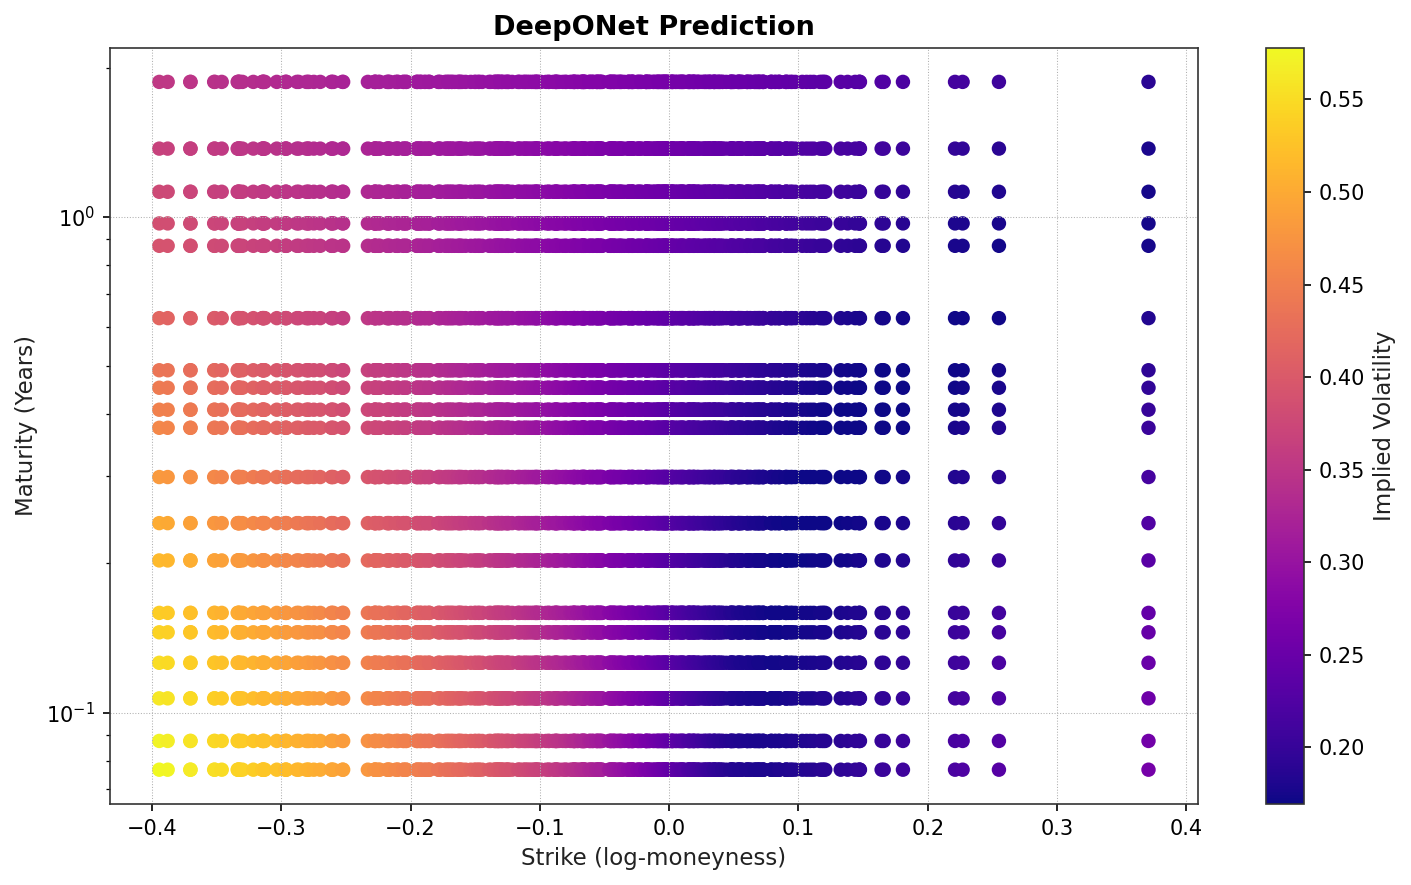

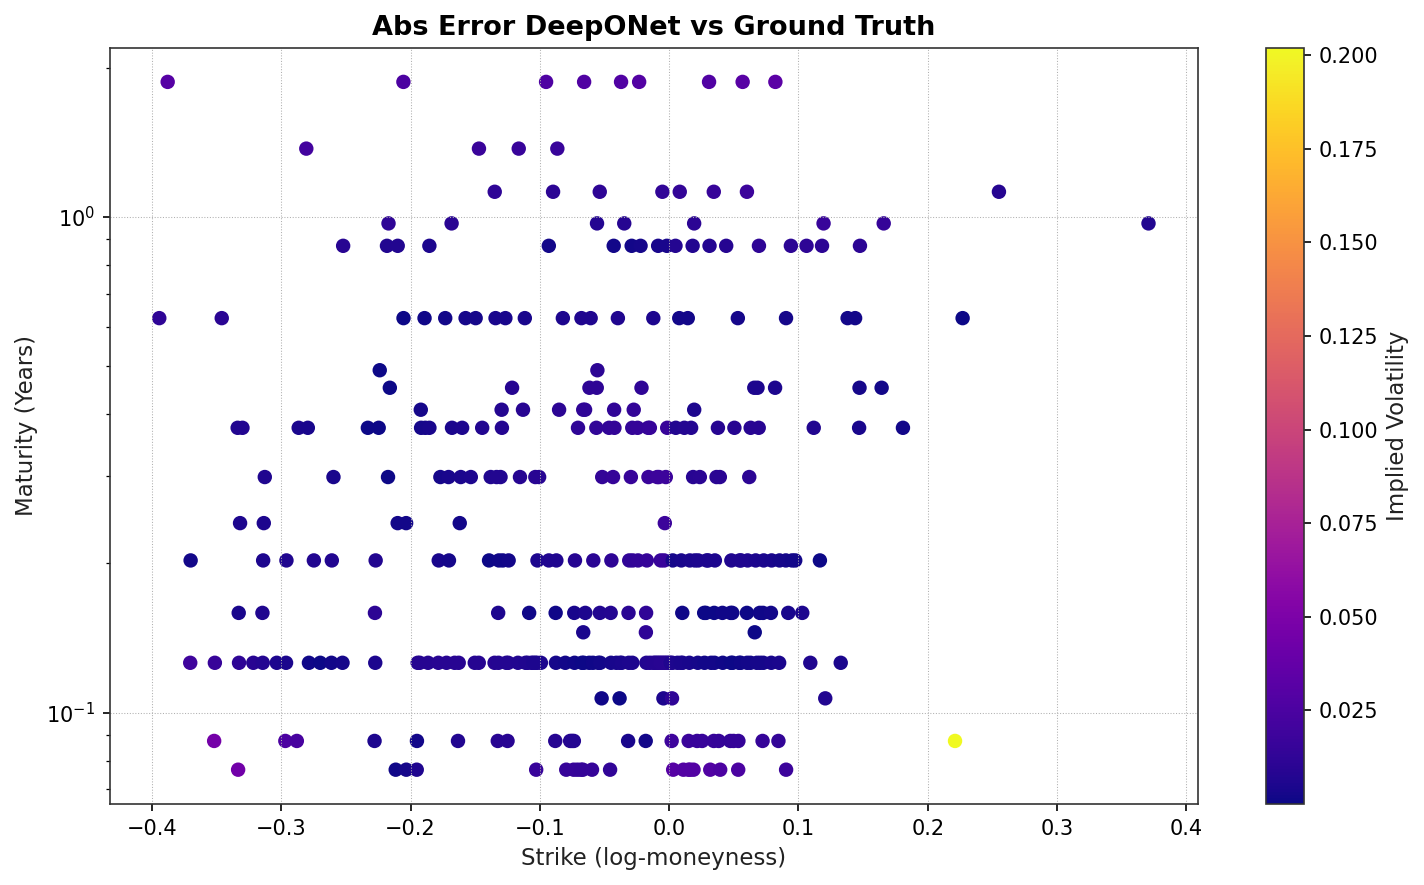

In [6]:
j = 13

p = deeponet_res[j]["theta_hat"]
params = {n: p[i] for i, n in enumerate(x.param_names)}
k = x.predict_surface(params, grid=surfaces[j]["grid"]).detach().numpy()
print("RMSE: ",np.sqrt(np.nanmean((k-surfaces[j]["iv_surface"])**2)))
plot_iv_surface_scatter(surfaces[j]["iv_surface"],surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Ground Truth")
plot_iv_surface_scatter(k,surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="DeepONet Prediction")
plot_iv_surface_scatter(np.abs(k-surfaces[j]["iv_surface"]),surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Abs Error DeepONet vs Ground Truth")